In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [5]:
%load_ext autoreload
%autoreload 2
from appF_diagnostic import *

In [6]:
DEVICE = 'cuda'
n = 512
aspect_ratio = 4
# spectrum = torch.cat((
#     torch.logspace(-0.01, -2, steps=16, dtype=torch.float64, device=DEVICE),
#     torch.zeros(n - 16, dtype=torch.float64, device=DEVICE),
# ))
spectrum = torch.logspace(-0.01, -8, steps=n, dtype=torch.float64, device=DEVICE)
assert torch.all(spectrum[:-1] >= spectrum[1:]), "spectrum must be decreasing"
G = spectrum2matrix(spectrum, aspect_ratio)
# G = torch.diag(spectrum)

PE = PolarExpressDiagnostic(
    coeffs_name="ns3",
    steps=20,
    restarts=[],
    force_symmetry=True,
    ambient_dtype=torch.float64,
    xxt_dtype=torch.float16,
    do_diagnostics=True,
)
out, diagnostics = PE(G)
df = pd.DataFrame(diagnostics)
# since Z and Q are decreasing functions of the corresponding singular value of X_0, flip them for plotting purposes
df['Z_singvals'] = df['Z_singvals'].apply(np.flip)
df['Q_singvals'] = df['Q_singvals'].apply(np.flip)

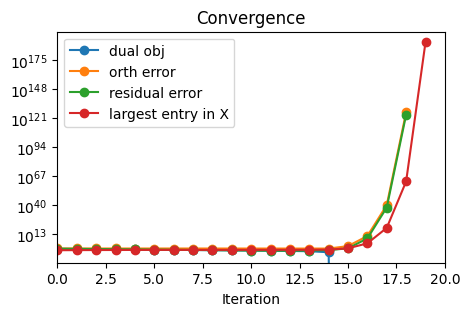

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(df['dual_obj'], marker='o', label='dual obj')
ax.plot(df['orth_error'], marker='o', label='orth error')
ax.plot(df['residual_error'], marker='o', label='residual error')
ax.plot(df['X_largest_entry'], marker='o', label='largest entry in X')

for restart in PE.restarts:
    ax.axvline(x=restart - 0.5, color='black', linestyle='dashed', linewidth=0.5)

ax.set_title("Convergence")
ax.set_xlabel("Iteration")
ax.set_yscale("log")
ax.set_xlim(0, len(df) - 1)
ax.legend();

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

spectrum_cpu = spectrum.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
columns = ['R_singvals_from_starting_vecs', 'Z_singvals_from_starting_vecs', 'Q_singvals_from_starting_vecs', 'X_singvals_from_starting_vecs']
# columns = ['R_singvals', 'Z_singvals', 'Q_singvals', 'X_singvals']
titles = ['R eigvals', 'Z eigvals', 'Q eigvals', 'X singvals']

def update(frame):
    for ax, col, title in zip(axes, columns, titles):
        vals = df[col].iloc[frame]
        ax.plot(spectrum_cpu, vals, label=f'step {frame}')
        ax.set_title(f'{title} (steps 0 – {frame})')
        ax.set_xlabel('X_0 eigenvalues')
        ax.legend(loc='upper right', fontsize='small')

ani = FuncAnimation(fig, update, frames=len(df), init_func=lambda: [], interval=500, repeat=False)
plt.close(fig)
HTML(ani.to_jshtml())